### Visualization of GBM tumor-model pairs 


This notebook provides an example of the visualization of GBM pairs provided in in Fig. 3d.


Setup user-defined parameters. Provide the full path to "HCMI_snRNAseq_data_metadata" as `Work_dir` and the full path to the current GitHub (parent) directory as `Code_dir`.

In [1]:
cohort = "GBM"

Work_dir = "/Users/lucazanella7/Library/Group Containers/G69SCX94XU.duck/Library/Application Support/duck/Volumes.noindex/hpc_ac2248_gp.localized/shares/hcmi/single-nuclei/HCMI_snRNAseq_data_metadata/" #"/groups/ac2248_gp/shares/hcmi/single-nuclei/HCMI_snRNAseq_data_metadata/" # parent directory for input data
Code_dir = "/Users/lucazanella7/Desktop/ColumbiaProjects/hcmi-analysis-califano-lab/" #"/groups/ac2248_gp/lz2841/ColumbiaProjects/hcmi-analysis-califano-lab/" # path to GitHub folder

Other settings include the reference population for data centering, the number of targt genes in each regulon for network pruning and scaling and graphic parameters.

In [2]:
reference = "centroid" 
n_targets_VIPER = 100
pval_NaRnEA = 0.15


Paths to directory collecting markers and demultiplexed input data are specified below.

In [3]:
filtering_level_vcf = "filtered_01" # "no_filtered": VCFs; "filtered": VCFs filtered at MAF>=1%, "filtered_01": VCFs filtered at MAF >=0.1%
sample_assignment = "best_gt_thresh" # "best_gt_thresh"; "sng1st_gt"

# Postprocessing filtering_level_vcf
if filtering_level_vcf == "no_filtered":
    filtering_level_vcf = ""
elif filtering_level_vcf == "filtered":
    filtering_level_vcf = "-filtered"
elif filtering_level_vcf == "filtered_01":
    filtering_level_vcf = "-filtered-01"
else:
    print("Unknown value provided for filtering_level_vcf")

markers_dir = f"{Code_dir}single-nuclei/markers/" # path to directory collecting gene expression markers

Specify cases in the cohort

In [4]:
cases=["HCM-BROD-0416-C71", "HCM-BROD-0213-C71", "HCM-BROD-0028-C71", "HCM-BROD-0415-C71", "HCM-BROD-0199-C71", "HCM-BROD-0012-C71", "HCM-BROD-0002-C71"]

Import packages and custom functions

In [5]:
import sys
import scanpy as sc
import numpy as np 
from numpy import nanmedian, NaN
import pandas as pd
import os 
from matplotlib import rc_context
import seaborn as sns
import matplotlib.pyplot as plt
import pyviper
sc.settings.verbosity = 0
sc.logging.print_header()
sc.settings.set_figure_params(frameon=False, dpi=100, facecolor="white")
from matplotlib.backends.backend_pdf import PdfPages
import hdf5plugin
import argparse
import anndata
import gc
from contextlib import contextmanager
import warnings
warnings.simplefilter("ignore", category=UserWarning)
from scipy.sparse import issparse
import re
from matplotlib.colors import LinearSegmentedColormap
from itertools import compress
from scipy.stats import combine_pvalues
import math
sys.path.append(f'{Code_dir}/single-nuclei/funcs/')
from processing_funcs import *

# Custom function: retrieving putative malignant cells
def process_clusters(clusters_putative_malignant):
    # Extract the value from the Series (assuming a single element in the Series)
    cluster_value = clusters_putative_malignant.values[0]
    
    # Check if the value is "all"
    if isinstance(cluster_value, str) and cluster_value.lower() == "all":
        return cluster_value
    # If it's a comma-separated string, split it into a list of integers
    elif isinstance(cluster_value, str) and "," in cluster_value:
        return [int(i) for i in cluster_value.split(",")]
    # If it's a single integer, wrap it in a list
    else:
        return [int(cluster_value)]
    
# Specify other graphic parameters
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 7

/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/loompy/bus_file.py:68: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def twobit_to_dna(twobit: int, size: int) -> str:
/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/loompy/bus_file.py:85: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' 

scanpy==1.9.3 anndata==0.10.8 umap==0.5.3 numpy==1.24.3 scipy==1.11.1 pandas==2.2.2 scikit-learn==1.1.3 statsmodels==0.14.0 python-igraph==0.10.8 louvain==0.8.1 pynndescent==0.5.10


/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/umap/umap_.py:660: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()


Load snRNA-seq metadata.

In [6]:
snRNAseq_metadata_path = f"{Code_dir}single-nuclei/Matched Model_Tumor for Sequencing.xlsx"
snRNAseq_metadata = pd.read_excel(snRNAseq_metadata_path, sheet_name="Samplesheet_for_Analysis")

Load snRNA-seq data and subset for putative malignant cells only

In [7]:
adata_samples = {}  # initialize dictionary collecting AnnData object
samples_metadata_path = f"{Work_dir}/metadata/" # path to gene expression metadata
for case in cases:

    print(f"Case: {case}")

    case_metadata = snRNAseq_metadata[snRNAseq_metadata["Case ID"] == case] # subset for the Case ID being analyzed
    # Automatically define sample names and paths to data
    samples = [f'{case_metadata.loc[idx,"Multiplex (GEM) ID"]}_{case}' for idx in case_metadata.index] # samples names
    file_paths = {ID: f"{Work_dir}demultiplexed_samples_{sample_assignment}{filtering_level_vcf}/{ID}_gt.h5ad" for ID in samples} # path to data


    # Load snRNA-seq metadata
    for sample, path in file_paths.items():
        # Load gene expression data and include it into AnnData object
        print('Loading ID',sample,end=' ')
        adata_samples[sample] = sc.read_h5ad(filename=path) # adata
        adata_samples[sample].var_names_make_unique()
        adata_samples[sample].obs["Sample Type"] = adata_samples[sample].obs["Sample Type"].str.rstrip() # strip spaces from Sample Type
        print(': AnnData of dimensions',adata_samples[sample].shape)
        # Subset for only the cells that previously passed QC and then only for putative malignant cells
        sample_metadata_path = f"{samples_metadata_path}{sample}-metadata.tsv"
        sample_infercnv_path = f"{samples_metadata_path}{sample}-chrs-infercnv.tsv"
        clusters_putative_malignant = case_metadata[case_metadata["Sample ID snRNAseq"] == sample]["Putative malignant clusters"]

        sample_metadata = pd.read_csv(sample_metadata_path, sep="\t")
        sample_infercnv = pd.read_csv(sample_infercnv_path, sep="\t")


        columns_to_add_metadata = sample_metadata.columns.difference(adata_samples[sample].obs.columns)
        sample_metadata = sample_metadata[columns_to_add_metadata]

        # subset for cells retained in the metadata table
        print("Subsetting only for putative tumor cells")

        cohort = list(case_metadata[case_metadata["Sample ID snRNAseq"] == sample]["Cohort"])[0]

        adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs.index.isin(sample_metadata["barcode"])]
        adata_samples[sample].obs = adata_samples[sample].obs.merge(sample_metadata, left_on='barcode', right_on="barcode", how='left') # attach metadata
        
        # subset of only putative malignant cells
        clusters_putative_malignant = process_clusters(clusters_putative_malignant)
        if clusters_putative_malignant != "all":
            adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs["clusters"].isin(clusters_putative_malignant)]

            if cohort == "PDAC":
                adata_samples[sample].obs.set_index("barcode", inplace=True) # set index
                adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs["singler_BpE_cg"] == "Epithelial cells"]

        adata_samples[sample].obs.set_index("barcode", inplace=True) # set indewx
        sc.pp.calculate_qc_metrics(adata_samples[sample], qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)


    # Gene selection
    gene_names = adata_samples[sample].var_names # assume gene names are the same across all samples
    gene_counts = np.zeros(len(gene_names))
    # Iterate over each sample and accumulate the counts
    for sample, adata in adata_samples.items():
        if issparse(adata.X):
            gene_counts += np.array(adata.X.sum(axis=0)).flatten()
        else:
            gene_counts += np.sum(adata.X, axis=0)
    # Convert to DataFrame for better readability
    gene_counts_df = pd.DataFrame(data=gene_counts, index=gene_names, columns=['Total_Counts'])
    genes_retain = gene_counts_df[gene_counts_df["Total_Counts"] >= 10].index.to_list() # genes to retain 
    genes_retain = [str(gene) for gene in genes_retain]

    del gene_names, gene_counts, gene_counts_df
    gc.collect()

Case: HCM-BROD-0416-C71
Loading ID AG006_HCM-BROD-0416-C71 : AnnData of dimensions (8267, 38606)
Subsetting only for putative tumor cells
Loading ID AG007_HCM-BROD-0416-C71 : AnnData of dimensions (6130, 38606)
Subsetting only for putative tumor cells
Case: HCM-BROD-0213-C71
Loading ID AG006_HCM-BROD-0213-C71 : AnnData of dimensions (3318, 38606)
Subsetting only for putative tumor cells
Loading ID AG007_HCM-BROD-0213-C71 : AnnData of dimensions (20737, 38606)
Subsetting only for putative tumor cells
Case: HCM-BROD-0028-C71
Loading ID AG004_HCM-BROD-0028-C71 : AnnData of dimensions (26785, 38606)
Subsetting only for putative tumor cells
Loading ID AG005_HCM-BROD-0028-C71 : AnnData of dimensions (16175, 38606)
Subsetting only for putative tumor cells
Case: HCM-BROD-0415-C71
Loading ID AA016_HCM-BROD-0415-C71 : AnnData of dimensions (10615, 38606)
Subsetting only for putative tumor cells
Loading ID AA017_HCM-BROD-0415-C71 : AnnData of dimensions (4453, 38606)
Subsetting only for putative 

Perform gene filtering and concatenate samples 

In [8]:
samples = list(adata_samples.keys())

for sample in samples:
    print(f"Gene filtering for {sample}")
    adata_samples[sample] = adata_samples[sample][:, genes_retain]

# Samples concatenation
adata_all = sc.concat(list(adata_samples.values()), axis = 0, join = 'outer') # integrate counts
adata_all.layers["counts"] = adata_all.X.copy()
adata_all.obs["Sample ID snRNAseq"] = pd.Categorical(adata_all.obs["Sample ID snRNAseq"], categories=samples, ordered=True) # order categories according to the samples list

adata_all.obs.index = adata_all.obs.index.astype(str) + "_" + adata_all.obs['Sample ID snRNAseq'].astype(str)

del adata_samples
gc.collect()

Gene filtering for AG006_HCM-BROD-0416-C71
Gene filtering for AG007_HCM-BROD-0416-C71
Gene filtering for AG006_HCM-BROD-0213-C71
Gene filtering for AG007_HCM-BROD-0213-C71
Gene filtering for AG004_HCM-BROD-0028-C71
Gene filtering for AG005_HCM-BROD-0028-C71
Gene filtering for AA016_HCM-BROD-0415-C71
Gene filtering for AA017_HCM-BROD-0415-C71
Gene filtering for AA014_HCM-BROD-0199-C71
Gene filtering for AA015_HCM-BROD-0199-C71
Gene filtering for AA014_HCM-BROD-0012-C71
Gene filtering for AA015_HCM-BROD-0012-C71
Gene filtering for AA016_HCM-BROD-0002-C71
Gene filtering for AA017_HCM-BROD-0002-C71


37615

Data preprocessing: normalization, centering and scaling based on the reference signature.

In [9]:
# Data preprocessing 
print("Normalizing (data); log-transforming (logdata); and scaling the data (scale) for. Setting scaled data as the defaut 'X'")
sc.pp.normalize_total(adata_all, target_sum=1e4, inplace=True) # normalize data 
sc.pp.log1p(adata_all) # logdata - log-normalization
adata_all.layers["logdata"] = adata_all.X.copy() # store logdata in the corresponding layer  

# Center with respect to the selected centroid
gene_reference = pd.read_csv(f"{Work_dir}GBM-malignant-reference-signature.tsv", sep="\t")
print("Using tumor-centroid as the reference to compute scaled_to_tumor_data.")
gene_reference = gene_reference.set_index("gene")  # Setting gene names as the index
gene_reference = gene_reference[gene_reference.index.isin(adata_all.var_names)]  # subset to match var_names
gene_reference = gene_reference.loc[adata_all.var_names]
gene_means = gene_reference['mean'].values
gene_stds = gene_reference['std'].values
gene_means = gene_means.reshape(1, -1)  # Reshape to (1, n_genes) to broadcast along the cell axis
gene_stds = gene_stds.reshape(1, -1)    # Reshape to (1, n_genes) for broadcasting

# Perform centering and scaling: (X - mean) / std
adata_all.layers["scaled_to_tumor_data"] = adata_all.layers["logdata"].copy()
adata_all.layers["scaled_to_tumor_data"] = (adata_all.layers["scaled_to_tumor_data"] - gene_means) / gene_stds
adata_all.layers["scaled_to_tumor_data"][adata_all.layers["scaled_to_tumor_data"] >= 10] = 10 # trim to 10 values that are above this value

print("Setting  'scale_to_tumor_data' as the default matrix. ")
adata_all.X = adata_all.layers["scaled_to_tumor_data"]
layer_enrichment = "scaled_to_tumor_data" # layer on which to perform the enrichment

Normalizing (data); log-transforming (logdata); and scaling the data (scale) for. Setting scaled data as the defaut 'X'
Using tumor-centroid as the reference to compute scaled_to_tumor_data.
Setting  'scale_to_tumor_data' as the default matrix. 


Load GBM gene sets from [Neftel et. al, 2019](https://www.cell.com/cell/fulltext/S0092-8674(19)30687-7?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0092867419306877%3Fshowall%3Dtrue).

In [10]:
# Suva' Lab markers
Suva_gene_sets = pd.read_excel(f"{markers_dir}GBM-markers.xlsx", sheet_name="S2_Neftel") 
Suva_gene_sets.drop(columns=['G1/S', 'G2/M'], inplace=True)
#Suva_gene_sets = Suva_gene_sets.rename(columns=lambda x: x + " subtype")
Suva_network = pd.melt(Suva_gene_sets, var_name='regulator', value_name='target').dropna(subset=['target'])
Suva_network["mor"] = 1
Suva_network["likelihood"] = 1
Suva_network = Suva_network.drop_duplicates(subset=['regulator', 'target'])
Suva_network = pyviper.Interactome('lineage_markers', Suva_network) # convet to interactome
Suva_network.net_table["regulator"] = Suva_network.net_table["regulator"].str.replace("-like","")

Compute the enrichment and collapse MES1, MES2 into MES and NPC1, NPC2 into NPC

In [11]:
# compute the enrichment
Suva_enr_nn = pyviper.tl.path_enr(adata_all, pathway_interactome=Suva_network, layer=layer_enrichment, enrichment="narnea", verbose="False", store_input_data=False)

# Combine the MES-like and NPC-like subtypes
MES = Suva_enr_nn[:, ['MES1', 'MES2']].X
NPC = Suva_enr_nn[:, ['NPC1', 'NPC2']].X
MES_like = MES.max(axis=1)
NPC_like = NPC.max(axis=1)

Suva_enr_nn.obs['MES'] = MES_like # add it as new var
Suva_enr_nn.obs['NPC'] = NPC_like # add it as new var


Removed 14 targets.
Preparing the association scores
Computing regulons enrichment with NaRnEa


/Users/lucazanella7/Desktop/ColumbiaProjects/pyviper/pyviper/_NaRnEA/NaRnEA_classic.py:200: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  filtered_table['mor'].replace(1 ,0.999, inplace= True)


reordering genes
Calculating DES...
Calculating UES...
Calculating NES...
Calculating PES...


Assign cellular states to individual nuclei

In [12]:
sorted_pathways = ['MES', 'NPC', 'AC', 'OPC']

mes_values = Suva_enr_nn.obs["MES"].values
npc_values = Suva_enr_nn.obs["NPC"].values
X_selected = Suva_enr_nn[:, ["AC", "OPC"]].X
new_var = Suva_enr_nn.var.loc[["AC", "OPC"]].copy()
new_var = pd.concat([new_var, pd.DataFrame(index=["MES", "NPC"])])
X_combined = np.hstack([X_selected, mes_values[:, None], npc_values[:, None]])
Suva_enr_nn_states = anndata.AnnData(X=X_combined, obs=Suva_enr_nn.obs, var=new_var)
del Suva_enr_nn

nes_pvals = pyviper._pp._nes_to_pval_df(Suva_enr_nn_states.to_df(), lower_tail=False, adjust=False) # cell type which has highest P value 
Suva_enr_nn_states.obs["NaRnEA_tumor_centroid"] = nes_pvals.apply(get_top_cell_types, axis=1, top_n = 1, pval_threshold=pval_NaRnEA) # assign cell state with lowest P values

# Concatenate NES scores for subtypes and subtype assignment to adata_all
adata_all.obs = adata_all.obs.merge(Suva_enr_nn_states.to_df(), left_index=True, right_index=True, how="left")
adata_all.obs = adata_all.obs.merge(Suva_enr_nn_states.obs["NaRnEA_tumor_centroid"], left_index=True, right_index=True, how="left")

### Generate Protein Actvity profile for PCA visualization
Load ARACNe-inferred gene regulatory networks for GBM.

In [13]:
#Load gene regulatory networks
net_dir = f"{Work_dir}GBM-networks/"
GBM_integrated_path = f"{net_dir}GBM_integrated_nets_metacells.tsv"
GBM_integrated_net = pyviper.Interactome("GBM-integrated-net", net_table=GBM_integrated_path) # load integrated network from multiple GBM patients


# filter and prune networks to the desired number of target genes
GBM_integrated_net.filter_targets(adata_all.var_names) # filter networks
GBM_integrated_net.prune(max_targets=n_targets_VIPER,eliminate=False) # prune networks

Removed 457740 targets.
Removed 2635048 targets.
Removed 0 regulators.


(Just a technical steps: split `adata_all` into different samples to reduce memory usage later on.)

In [14]:
adata_cases = {}
for case in cases:
    print(f"Splitting adata_all for {case}")
    adata_cases[case] = adata_all[adata_all.obs["Case ID"] == case,:].copy()

del adata_all, Suva_enr_nn_states
gc.collect()
gc.collect()

Splitting adata_all for HCM-BROD-0416-C71
Splitting adata_all for HCM-BROD-0213-C71
Splitting adata_all for HCM-BROD-0028-C71
Splitting adata_all for HCM-BROD-0415-C71
Splitting adata_all for HCM-BROD-0199-C71
Splitting adata_all for HCM-BROD-0012-C71
Splitting adata_all for HCM-BROD-0002-C71


0

Infer Protein Activity using VIPER (this can take a few minutes).

In [15]:
# Inferring Protein Activity using VIPER
adata_PA = {}
for case in cases:
    print(f"Runnig VIPER on single-cell network for {case}")
    adata_PA[case] = pyviper.viper(gex_data=adata_cases[case], interactome=GBM_integrated_net, enrichment="narnea", eset_filter=False, output_as_anndata=True, store_input_data=False, verbose=False) # VIPER on integrated network

Runnig VIPER on single-cell network for HCM-BROD-0416-C71


/Users/lucazanella7/Desktop/ColumbiaProjects/pyviper/pyviper/_NaRnEA/NaRnEA_classic.py:200: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  filtered_table['mor'].replace(1 ,0.999, inplace= True)
/Users/lucazanella7/Desktop/ColumbiaProjects/pyviper/pyviper/_NaRnEA/NaRnEA_classic.py:201: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which 

Runnig VIPER on single-cell network for HCM-BROD-0213-C71


/Users/lucazanella7/Desktop/ColumbiaProjects/pyviper/pyviper/_NaRnEA/NaRnEA_classic.py:200: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  filtered_table['mor'].replace(1 ,0.999, inplace= True)
/Users/lucazanella7/Desktop/ColumbiaProjects/pyviper/pyviper/_NaRnEA/NaRnEA_classic.py:201: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which 

Runnig VIPER on single-cell network for HCM-BROD-0028-C71


...

/Users/lucazanella7/Desktop/ColumbiaProjects/pyviper/pyviper/_NaRnEA/NaRnEA_classic.py:200: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  filtered_table['mor'].replace(1 ,0.999, inplace= True)
/Users/lucazanella7/Desktop/ColumbiaProjects/pyviper/pyviper/_NaRnEA/NaRnEA_classic.py:201: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which 

Runnig VIPER on single-cell network for HCM-BROD-0012-C71


/Users/lucazanella7/Desktop/ColumbiaProjects/pyviper/pyviper/_NaRnEA/NaRnEA_classic.py:200: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  filtered_table['mor'].replace(1 ,0.999, inplace= True)
/Users/lucazanella7/Desktop/ColumbiaProjects/pyviper/pyviper/_NaRnEA/NaRnEA_classic.py:201: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which 

Runnig VIPER on single-cell network for HCM-BROD-0002-C71


/Users/lucazanella7/Desktop/ColumbiaProjects/pyviper/pyviper/_NaRnEA/NaRnEA_classic.py:200: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  filtered_table['mor'].replace(1 ,0.999, inplace= True)
/Users/lucazanella7/Desktop/ColumbiaProjects/pyviper/pyviper/_NaRnEA/NaRnEA_classic.py:201: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which 

Dimensionality Reduction: run PCA on the pritein activity matrix for each case (i.e., sample pair)

In [16]:
# Generating PCA projection by case
for case in cases:
    print(f"Run PCA for {case}")
    # J.3) Run PCA and UMAP at the protein activity level
    sc.tl.pca(adata_PA[case], svd_solver="arpack") # run PCA
    sc.tl.embedding_density(adata_PA[case], basis='pca', groupby='Tumor or Model') # calculate density on PCA using KDE

Run PCA for HCM-BROD-0416-C71
Run PCA for HCM-BROD-0213-C71
Run PCA for HCM-BROD-0028-C71
Run PCA for HCM-BROD-0415-C71
Run PCA for HCM-BROD-0199-C71
Run PCA for HCM-BROD-0012-C71
Run PCA for HCM-BROD-0002-C71


Single-case Protein Activity visualization. Define some plotting parameters.

In [17]:
tab20 = plt.get_cmap("tab20")

# Define the specific colors you want to use
T_M_colors = {
    "T": "#8dd3c7",  # Green for Tumor (T)
    "M": "#ffffb3",  # Yellow for Model (M)
}

GBM_colormap = {
        'MES': '#AEC7E8',
        'AC': '#1F77B4',
        'NPC': '#98DF8A',
        'OPC': '#9467BD',
        'Normal': '#C5B0D5', 
        'Unknown': '#8C564B'             
    }

Display malignant cell populations on PCA space inferred from Protein Activity.

/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


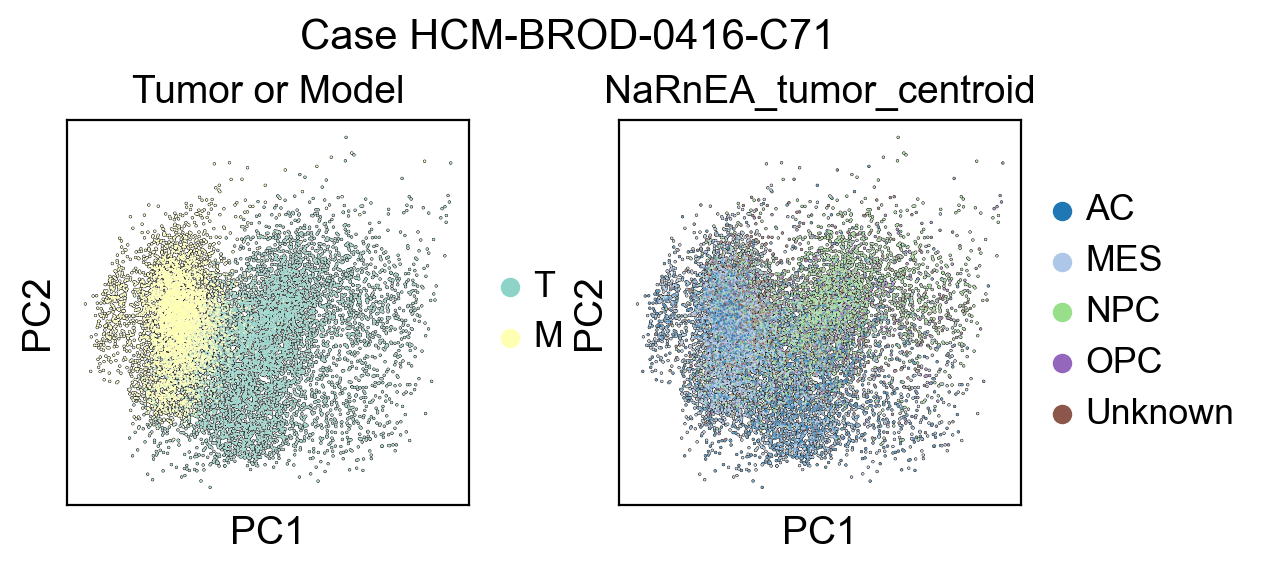

/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


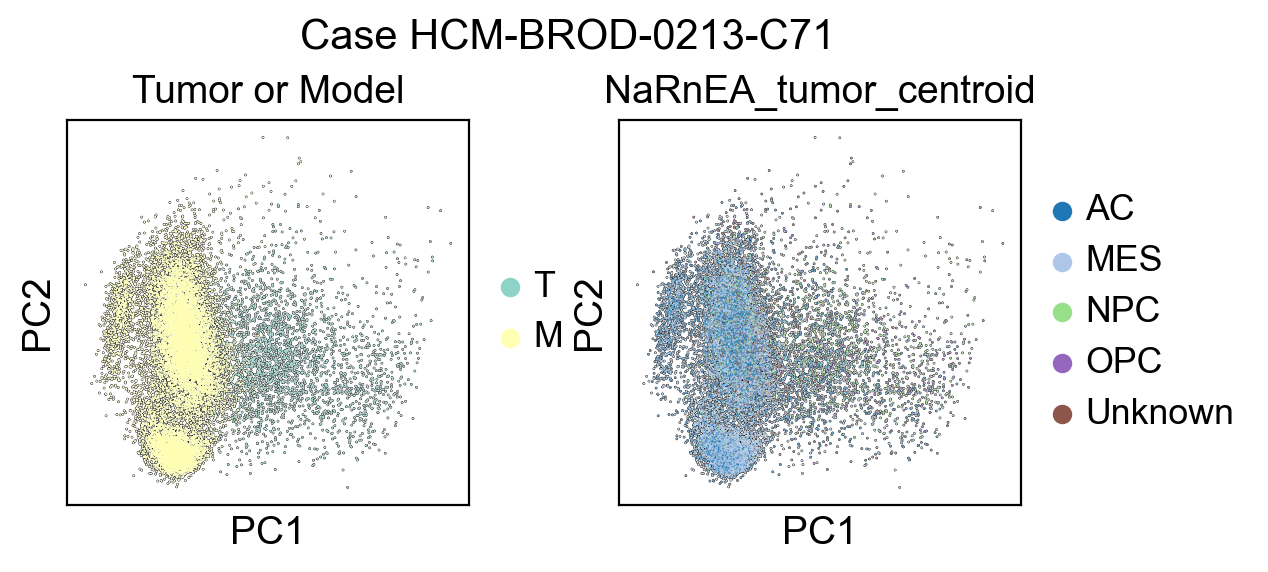

/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


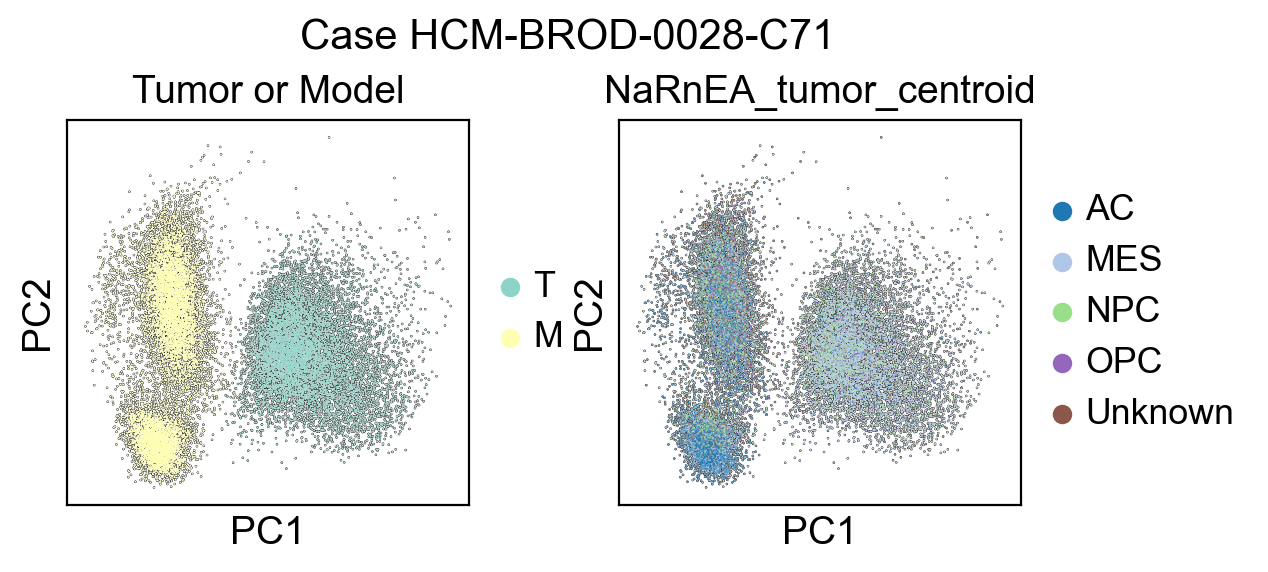

/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


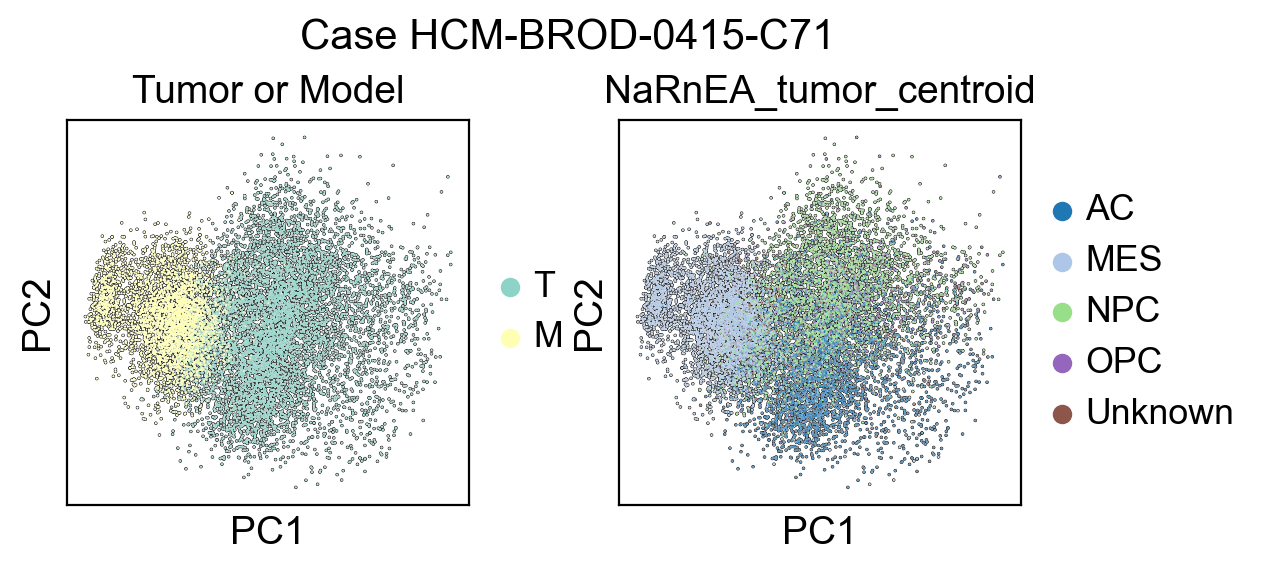

/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


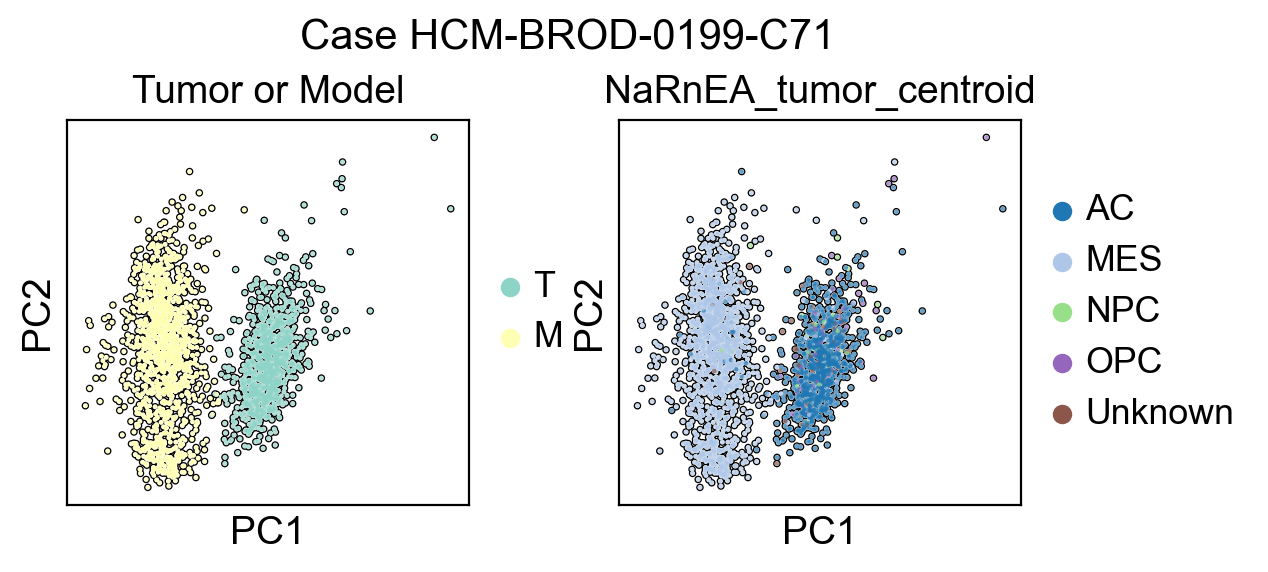

/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


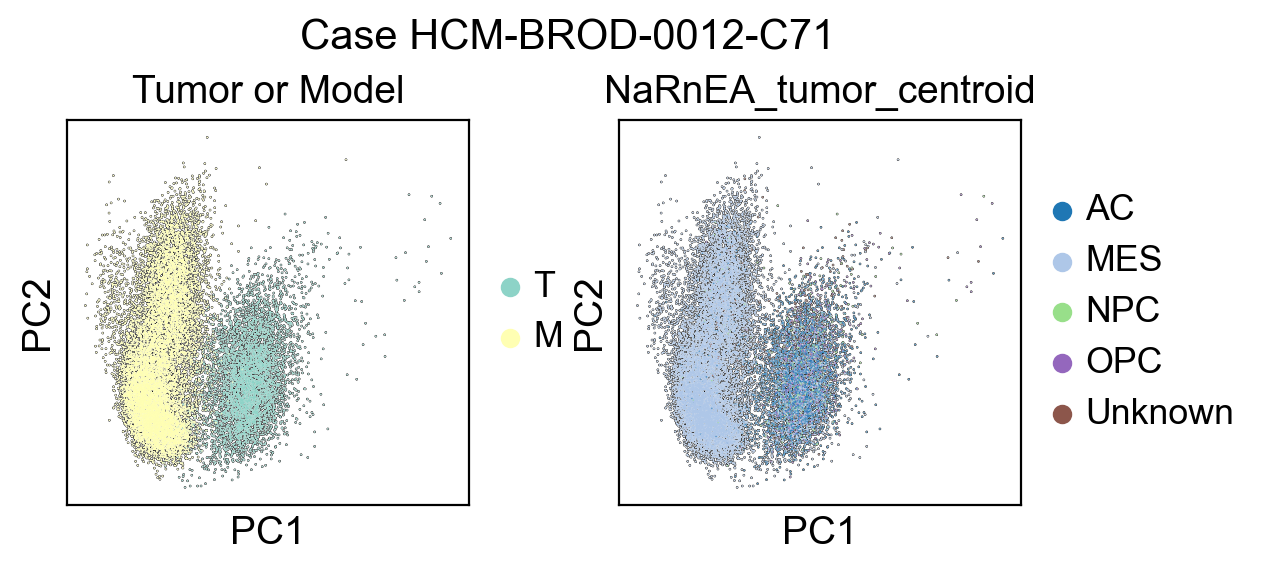

/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/lucazanella7/mambaforge/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


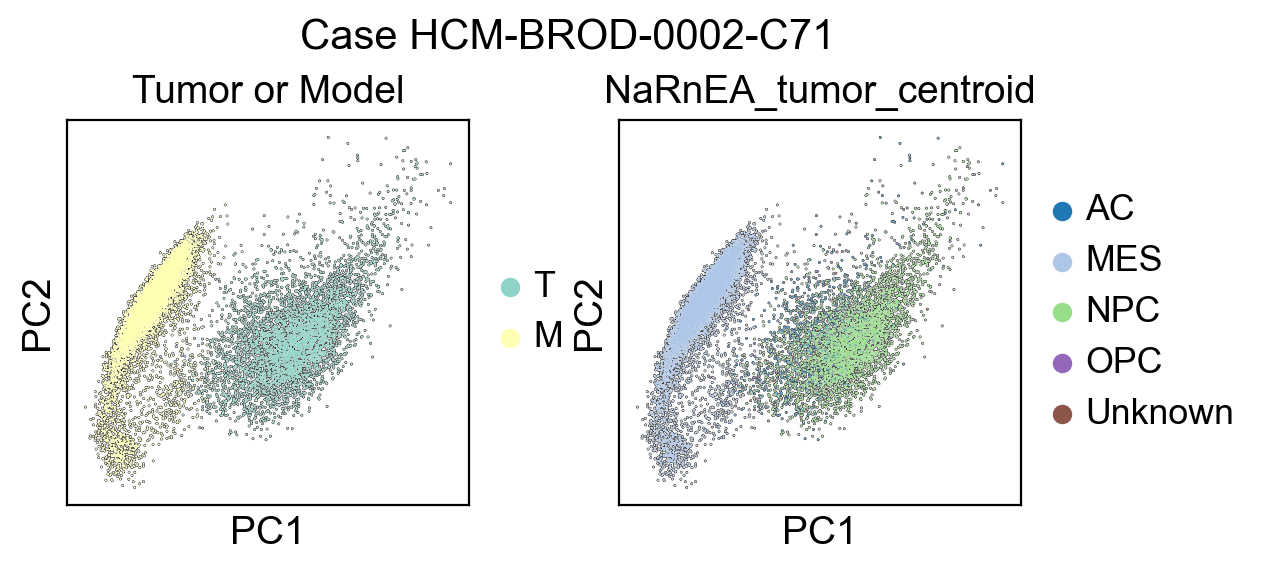

In [18]:
for case in cases:
    range_min = adata_PA[case].obs[sorted_pathways].min().min()
    range_max = adata_PA[case].obs[sorted_pathways].max().max()

    n_cells = adata_PA[case].shape[0]

    pt_size = 12000*2/n_cells

    adata_PA[case].obs["Tumor or Model"] = adata_PA[case].obs["Tumor or Model"].astype(pd.CategoricalDtype(categories=["T", "M"], ordered=True))


    # Assign colors to PA_NES_all
    adata_PA[case].uns["Tumor or Model_colors"] = [
        T_M_colors[ct] for ct in adata_PA[case].obs["Tumor or Model"].cat.categories if ct in T_M_colors]
    adata_PA[case].uns["NaRnEA_tumor_centroid_colors"] = [GBM_colormap[cat] for cat in adata_PA[case].obs["NaRnEA_tumor_centroid"].cat.categories]

    # Assignment
    title = f"{case}: Protein Activity (n={n_cells})"
    with rc_context({'figure.figsize': (2.5, 2.5)}):
        sc.pl.embedding(adata_PA[case], basis="pca", color=["Tumor or Model", "NaRnEA_tumor_centroid"], 
                        palette=None, size=pt_size, add_outline=True, frameon=True, 
                        wspace=0.25, vcenter=0, vmin=range_min, vmax=range_max, show=False, 
                        ncols=6, legend_fontweight="normal")

        plt.suptitle(f"Case {case}", fontsize=15, y=1.10)
        plt.show() 
            
    


Clean from some objects in memory

In [19]:
del adata_PA
gc.collect()

58276